# Phase D (standalone) — Accelerated Sampling & Demo, MVTec AD

This notebook is **self-contained**: it does not need Phase A/B/C to have been run in this
session. It loads the **already-trained MVTec AD checkpoint from Google Drive**
(`.../diffusion_project/phase_c/mvtec/checkpoints/latest.pt`), which the earlier Phase C
notebook already wrote there — so no training happens here, just loading + generation.

**Run every cell top to bottom, in order. Don't skip any.** There is nothing to choose or
toggle — this notebook always targets the MVTec AD model.

If the checkpoint isn't found, go back and run Phase C's MVTec stage first (that's the
only prerequisite).

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. Paths and config

Must match Phase C exactly — this is how we find the checkpoint.

In [2]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/diffusion_project/phase_c"
MVTEC_CKPT_DIR = os.path.join(PROJECT_ROOT, "mvtec", "checkpoints")
MVTEC_DRIVE_CKPT_PATH = os.path.join(MVTEC_CKPT_DIR, "latest.pt")

DRIVE_CACHE_DIR = "/content/drive/MyDrive/diffusion_project/mvtec_cache"
MVTEC_ROOT = "/content/mvtec_ad"
MVTEC_RAW_DIR = "/content/mvtec_ad_raw"

LOCAL_ROOT = "/content/local_work"
SAMPLES_DIR = os.path.join(LOCAL_ROOT, "samples")
for d in [LOCAL_ROOT, SAMPLES_DIR, MVTEC_ROOT, MVTEC_RAW_DIR]:
    os.makedirs(d, exist_ok=True)

IMAGE_SIZE = 64
TIMESTEPS = 1000

if not os.path.exists(MVTEC_DRIVE_CKPT_PATH):
    raise FileNotFoundError(
        f"No checkpoint found at {MVTEC_DRIVE_CKPT_PATH}.\n"
        f"This notebook only loads an already-trained model -- it doesn't train one. "
        f"Go run Phase C's MVTec AD stage first, then come back here."
    )
print(f"Found checkpoint: {MVTEC_DRIVE_CKPT_PATH}")


Found checkpoint: /content/drive/MyDrive/diffusion_project/phase_c/mvtec/checkpoints/latest.pt


## 3. Install dependencies

In [3]:
!pip install -q torch-fidelity gradio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 6.0 MB/s eta 0:00:00


## 4. Imports

In [4]:
import copy
import math
import time
import shutil
import random
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if device == "cpu":
    print("WARNING: no GPU detected. Go to Runtime -> Change runtime type -> GPU.")


Using device: cuda


## 5. Model architecture

Exact same classes as Phase C — needed to reconstruct the network before loading its
saved weights. Nothing here is trained; this just defines the shape of the model.

In [5]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        device = t.device
        half_dim = self.dim // 2
        freq_scale = math.log(10000) / (half_dim - 1)
        freqs = torch.exp(torch.arange(half_dim, device=device) * -freq_scale)
        args = t[:, None].float() * freqs[None, :]
        embedding = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2 == 1:
            embedding = F.pad(embedding, (0, 1))
        return embedding


class ResBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, cond_emb_dim: int, groups: int = 8):
        super().__init__()
        self.cond_mlp = nn.Sequential(nn.SiLU(), nn.Linear(cond_emb_dim, out_ch))
        self.block1 = nn.Sequential(
            nn.GroupNorm(groups, in_ch), nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        )
        self.block2 = nn.Sequential(
            nn.GroupNorm(groups, out_ch), nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
        )
        self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, cond_emb: torch.Tensor) -> torch.Tensor:
        h = self.block1(x)
        cond_bias = self.cond_mlp(cond_emb)
        h = h + cond_bias[:, :, None, None]
        h = self.block2(h)
        return h + self.skip(x)


class SelfAttention(nn.Module):
    def __init__(self, channels: int, num_heads: int = 4, groups: int = 8):
        super().__init__()
        self.norm = nn.GroupNorm(groups, channels)
        self.mha = nn.MultiheadAttention(channels, num_heads, batch_first=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, h, w = x.shape
        x_norm = self.norm(x)
        x_flat = x_norm.view(b, c, h * w).transpose(1, 2)
        attn_out, _ = self.mha(x_flat, x_flat, x_flat)
        attn_out = attn_out.transpose(1, 2).view(b, c, h, w)
        return x + attn_out


class Downsample(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.op = nn.Conv2d(channels, channels, kernel_size=3, stride=2, padding=1)
    def forward(self, x):
        return self.op(x)


class Upsample(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.op = nn.ConvTranspose2d(channels, channels, kernel_size=4, stride=2, padding=1)
    def forward(self, x):
        return self.op(x)


In [6]:
class UNet(nn.Module):
    """Class-conditional U-Net noise-prediction network. `num_classes` real classes
    plus ONE reserved "null" index (== num_classes) used for unconditional
    generation / CFG training dropout."""
    def __init__(
        self,
        in_channels: int = 3,
        base_channels: int = 64,
        channel_mults: tuple = (1, 2, 4, 8),
        time_emb_dim: int = 256,
        attention_resolutions: tuple = (16, 8),
        image_size: int = 64,
        num_classes: int = 47,
    ):
        super().__init__()
        self.num_classes = num_classes
        self.null_class_idx = num_classes

        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(base_channels),
            nn.Linear(base_channels, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        self.class_embed = nn.Embedding(num_classes + 1, base_channels)
        self.class_mlp = nn.Sequential(
            nn.Linear(base_channels, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        self.in_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)

        self.down_blocks = nn.ModuleList()
        ch = base_channels
        cur_res = image_size
        self.skip_channels = [ch]

        for mult in channel_mults:
            out_ch = base_channels * mult
            self.down_blocks.append(ResBlock(ch, out_ch, time_emb_dim))
            ch = out_ch
            self.skip_channels.append(ch)
            if cur_res in attention_resolutions:
                self.down_blocks.append(SelfAttention(ch))
            self.down_blocks.append(ResBlock(ch, ch, time_emb_dim))
            self.skip_channels.append(ch)
            if mult != channel_mults[-1]:
                self.down_blocks.append(Downsample(ch))
                cur_res //= 2

        self.mid_block1 = ResBlock(ch, ch, time_emb_dim)
        self.mid_attn = SelfAttention(ch)
        self.mid_block2 = ResBlock(ch, ch, time_emb_dim)

        self.up_blocks = nn.ModuleList()
        skips_to_consume = list(self.skip_channels)

        for i, mult in enumerate(reversed(channel_mults)):
            out_ch = base_channels * mult
            is_last_level = (i == len(channel_mults) - 1)
            num_resblocks = 3 if is_last_level else 2
            for _ in range(num_resblocks):
                skip_ch = skips_to_consume.pop()
                self.up_blocks.append(ResBlock(ch + skip_ch, out_ch, time_emb_dim))
                ch = out_ch
            if cur_res in attention_resolutions:
                self.up_blocks.append(SelfAttention(ch))
            if not is_last_level:
                self.up_blocks.append(Upsample(ch))
                cur_res *= 2

        self.out_norm = nn.GroupNorm(8, ch)
        self.out_conv = nn.Conv2d(ch, in_channels, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_embed(t)
        c_emb = self.class_mlp(self.class_embed(y))
        cond_emb = t_emb + c_emb

        h = self.in_conv(x)
        skips = [h]
        for layer in self.down_blocks:
            if isinstance(layer, ResBlock):
                h = layer(h, cond_emb)
                skips.append(h)
            else:
                h = layer(h)

        h = self.mid_block1(h, cond_emb)
        h = self.mid_attn(h)
        h = self.mid_block2(h, cond_emb)

        for layer in self.up_blocks:
            if isinstance(layer, ResBlock):
                skip = skips.pop()
                h = torch.cat([h, skip], dim=1)
                h = layer(h, cond_emb)
            else:
                h = layer(h)

        h = self.out_norm(h)
        h = F.silu(h)
        return self.out_conv(h)


## 6. Diffusion math (DDPM + DDIM, with classifier-free guidance)

Includes the fixes from the Phase C/D review: both samplers restore the model's original train/eval mode on exit instead of forcing `.train()`, and both take a `n_trajectory_frames` argument so DDPM and DDIM GIFs end up the same length regardless of how many denoising steps they actually run.

In [7]:
class GaussianDiffusion:
    def __init__(self, timesteps: int = 1000, beta_start: float = 1e-4, beta_end: float = 0.02, device: str = "cpu"):
        self.timesteps = timesteps
        self.device = device
        self.betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=device), self.alphas_cumprod[:-1]])
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.posterior_variance = self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)

    @staticmethod
    def _extract(values, t, shape):
        batch_size = t.shape[0]
        out = values.gather(0, t)
        return out.reshape(batch_size, *((1,) * (len(shape) - 1)))

    @torch.no_grad()
    def p_sample_cfg(self, model, x_t, t, y, guidance_scale):
        batch_size = x_t.shape[0]
        null_y = torch.full((batch_size,), model.null_class_idx, device=x_t.device, dtype=torch.long)

        eps_cond = model(x_t, t, y)
        eps_uncond = model(x_t, t, null_y)
        predicted_noise = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

        sqrt_ac_t = self._extract(self.sqrt_alphas_cumprod, t, x_t.shape)
        sqrt_1m_ac_t = self._extract(self.sqrt_one_minus_alphas_cumprod, t, x_t.shape)
        pred_x0 = (x_t - sqrt_1m_ac_t * predicted_noise) / sqrt_ac_t
        pred_x0 = pred_x0.clamp(-1.0, 1.0)  # static thresholding -- stops weak class embeddings collapsing

        alphas_cumprod_t = self._extract(self.alphas_cumprod, t, x_t.shape)
        alphas_cumprod_prev_t = self._extract(self.alphas_cumprod_prev, t, x_t.shape)
        alphas_t = self._extract(self.alphas, t, x_t.shape)
        betas_t = self._extract(self.betas, t, x_t.shape)

        posterior_mean = (
            torch.sqrt(alphas_cumprod_prev_t) * betas_t / (1.0 - alphas_cumprod_t) * pred_x0
            + torch.sqrt(alphas_t) * (1.0 - alphas_cumprod_prev_t) / (1.0 - alphas_cumprod_t) * x_t
        )

        if (t == 0).all():
            return posterior_mean
        posterior_var_t = self._extract(self.posterior_variance, t, x_t.shape)
        z = torch.randn_like(x_t)
        return posterior_mean + torch.sqrt(posterior_var_t) * z

    @torch.no_grad()
    def sample_cfg(self, model, image_shape, y, device, guidance_scale=3.0,
                    return_trajectory=False, n_trajectory_frames=12):
        was_training = model.training
        model.eval()
        try:
            x_t = torch.randn(image_shape, device=device)
            trajectory = [x_t.cpu()] if return_trajectory else None
            record_every = max(1, self.timesteps // n_trajectory_frames)
            for step in reversed(range(self.timesteps)):
                t_batch = torch.full((image_shape[0],), step, device=device, dtype=torch.long)
                x_t = self.p_sample_cfg(model, x_t, t_batch, y, guidance_scale)
                if return_trajectory and (step % record_every == 0):
                    trajectory.append(x_t.cpu())
        finally:
            model.train(was_training)
        return (x_t, trajectory) if return_trajectory else x_t

    @torch.no_grad()
    def ddim_sample_cfg(self, model, image_shape, y, device, guidance_scale=3.0,
                         ddim_steps=50, eta=0.0, return_trajectory=False, n_trajectory_frames=12):
        """Deterministic (eta=0) DDIM sampling with CFG, reusing the trained model
        unchanged. ddim_steps controls how many of the original `self.timesteps` steps
        are actually evaluated."""
        was_training = model.training
        model.eval()
        try:
            batch_size = image_shape[0]
            steps = sorted(set(np.linspace(0, self.timesteps - 1, ddim_steps).round().astype(int).tolist()))

            if return_trajectory:
                keep = set(np.linspace(0, len(steps) - 1, min(n_trajectory_frames, len(steps)))
                           .round().astype(int).tolist())
                keep.add(0)

            x_t = torch.randn(image_shape, device=device)
            trajectory = [x_t.cpu()] if return_trajectory else None
            null_y = torch.full((batch_size,), model.null_class_idx, device=device, dtype=torch.long)

            for i in reversed(range(len(steps))):
                step = steps[i]
                prev_step = steps[i - 1] if i > 0 else -1

                t_batch = torch.full((batch_size,), step, device=device, dtype=torch.long)
                eps_cond = model(x_t, t_batch, y)
                eps_uncond = model(x_t, t_batch, null_y)
                eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

                alpha_bar_t = self.alphas_cumprod[step]
                alpha_bar_prev = (self.alphas_cumprod[prev_step] if prev_step >= 0
                                  else torch.tensor(1.0, device=device))

                pred_x0 = (x_t - torch.sqrt(1.0 - alpha_bar_t) * eps) / torch.sqrt(alpha_bar_t)
                pred_x0 = pred_x0.clamp(-1.0, 1.0)

                if prev_step >= 0:
                    sigma_t = eta * torch.sqrt(
                        (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t) * (1.0 - alpha_bar_t / alpha_bar_prev)
                    )
                else:
                    sigma_t = torch.tensor(0.0, device=device)

                dir_xt = torch.sqrt((1.0 - alpha_bar_prev - sigma_t ** 2).clamp(min=0.0)) * eps
                noise = torch.randn_like(x_t) if (eta > 0.0 and prev_step >= 0) else torch.zeros_like(x_t)
                x_t = torch.sqrt(alpha_bar_prev) * pred_x0 + dir_xt + sigma_t * noise

                if return_trajectory and i in keep:
                    trajectory.append(x_t.cpu())
        finally:
            model.train(was_training)
        return (x_t, trajectory) if return_trajectory else x_t


def denormalize(images: torch.Tensor) -> torch.Tensor:
    return (images.clamp(-1, 1) + 1) / 2


class EMA:
    """Holds the smoothed weights -- always sample from ema_model, never the raw model."""
    def __init__(self, model: nn.Module, decay: float = 0.995):
        self.decay = decay
        self.ema_model = copy.deepcopy(model).eval()
        for p in self.ema_model.parameters():
            p.requires_grad_(False)

    def state_dict(self):
        return self.ema_model.state_dict()

    def load_state_dict(self, state_dict):
        self.ema_model.load_state_dict(state_dict)


## 7. Load the trained MVTec AD checkpoint

No training happens in this notebook — this just rebuilds the model shape and loads Phase C's saved weights into it.

In [8]:
ckpt = torch.load(MVTEC_DRIVE_CKPT_PATH, map_location=device, weights_only=False)
mvtec_config = ckpt["config"]
MVTEC_CATEGORIES = mvtec_config["class_names"]
NUM_CLASSES_MVTEC = mvtec_config["num_classes"]
IMAGE_SIZE = mvtec_config.get("image_size", IMAGE_SIZE)
TIMESTEPS = mvtec_config.get("timesteps", TIMESTEPS)

mvtec_model = UNet(in_channels=3, base_channels=64, image_size=IMAGE_SIZE,
                    num_classes=NUM_CLASSES_MVTEC).to(device)
mvtec_model.load_state_dict(ckpt["model_state_dict"])

mvtec_diffusion = GaussianDiffusion(timesteps=TIMESTEPS, device=device)

mvtec_ema = EMA(mvtec_model)
if ckpt.get("ema_state_dict") is not None:
    mvtec_ema.load_state_dict(ckpt["ema_state_dict"])
    print("Loaded EMA weights from checkpoint.")
else:
    print("No EMA weights in this checkpoint -- EMA initialized from raw model weights.")

# All sampling below uses pd_ema.ema_model, never mvtec_model directly.
pd_model, pd_ema, pd_diffusion = mvtec_model, mvtec_ema, mvtec_diffusion
pd_class_names = list(MVTEC_CATEGORIES)
pd_num_classes = NUM_CLASSES_MVTEC

print(f"Checkpoint epoch: {ckpt.get('epoch')}")
print(f"Classes ({pd_num_classes}): {pd_class_names}")
print(f"Image size: {IMAGE_SIZE}, timesteps: {TIMESTEPS}")


No EMA weights in this checkpoint -- EMA initialized from raw model weights.
Checkpoint epoch: 39
Classes (6): ['carpet', 'grid', 'leather', 'metal_nut', 'tile', 'wood']
Image size: 64, timesteps: 1000


## 8. Fetch real MVTec images (for the FID quality benchmark only)

Only needed so the FID score in section 10 has real reference images to compare against. Pulls from the Drive cache Phase C already created, so this should be fast and shouldn't re-download from the internet.

In [9]:
import tarfile

def archive_is_valid(path):
    try:
        with tarfile.open(path) as tar:
            tar.getmembers()
        return True
    except Exception:
        return False

for name in MVTEC_CATEGORIES:
    dest = os.path.join(MVTEC_RAW_DIR, f"{name}.tar.xz")
    drive_dest = os.path.join(DRIVE_CACHE_DIR, f"{name}.tar.xz")
    extracted_marker = os.path.join(MVTEC_ROOT, name, "train", "good")

    if os.path.isdir(extracted_marker) and os.listdir(extracted_marker):
        print(f"{name}: already extracted, skipping.")
        continue

    if os.path.exists(drive_dest) and archive_is_valid(drive_dest):
        print(f"{name}: copying valid cached copy from Drive.")
        shutil.copy(drive_dest, dest)
    elif not os.path.exists(dest) or not archive_is_valid(dest):
        raise FileNotFoundError(
            f"No cached archive found for '{name}' at {drive_dest}, and it wasn't downloaded "
            f"earlier in this session either. Run Phase C's MVTec download cell once (it caches "
            f"to Drive permanently), then re-run this cell."
        )

    print(f"  extracting {name} ...")
    with tarfile.open(dest) as tar:
        tar.extractall(MVTEC_ROOT)

print("MVTec categories on disk:", os.listdir(MVTEC_ROOT))


carpet: copying valid cached copy from Drive.
  extracting carpet ...


/tmp/ipykernel_2333/3793843259.py:32: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(MVTEC_ROOT)


grid: copying valid cached copy from Drive.
  extracting grid ...
leather: copying valid cached copy from Drive.
  extracting leather ...
metal_nut: copying valid cached copy from Drive.
  extracting metal_nut ...
tile: copying valid cached copy from Drive.
  extracting tile ...
wood: copying valid cached copy from Drive.
  extracting wood ...
MVTec categories on disk: ['leather', 'grid', 'tile', 'metal_nut', 'wood', 'carpet']


In [10]:
class MVTecNormalDataset(Dataset):
    """Walks train/good for each category -- defect-free images only."""
    def __init__(self, root, categories, transform=None):
        self.transform = transform
        self.categories = categories
        self.samples = []
        for idx, category in enumerate(categories):
            good_dir = os.path.join(root, category, "train", "good")
            if not os.path.isdir(good_dir):
                continue
            for fname in sorted(os.listdir(good_dir)):
                if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                    self.samples.append((os.path.join(good_dir, fname), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        from PIL import Image
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, label


# Deterministic transform (no random flip) -- this is a reference set for FID, not training data.
fid_eval_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
pd_real_dataset = MVTecNormalDataset(MVTEC_ROOT, MVTEC_CATEGORIES, transform=fid_eval_transform)
print(f"Real reference images available: {len(pd_real_dataset)}")


Real reference images available: 1486


## 9. Sanity check — DDPM vs. DDIM at a few step counts

Same trained weights, different sampler. DDIM at 50-100 steps should look close to the full 1000-step DDPM row for the same class.

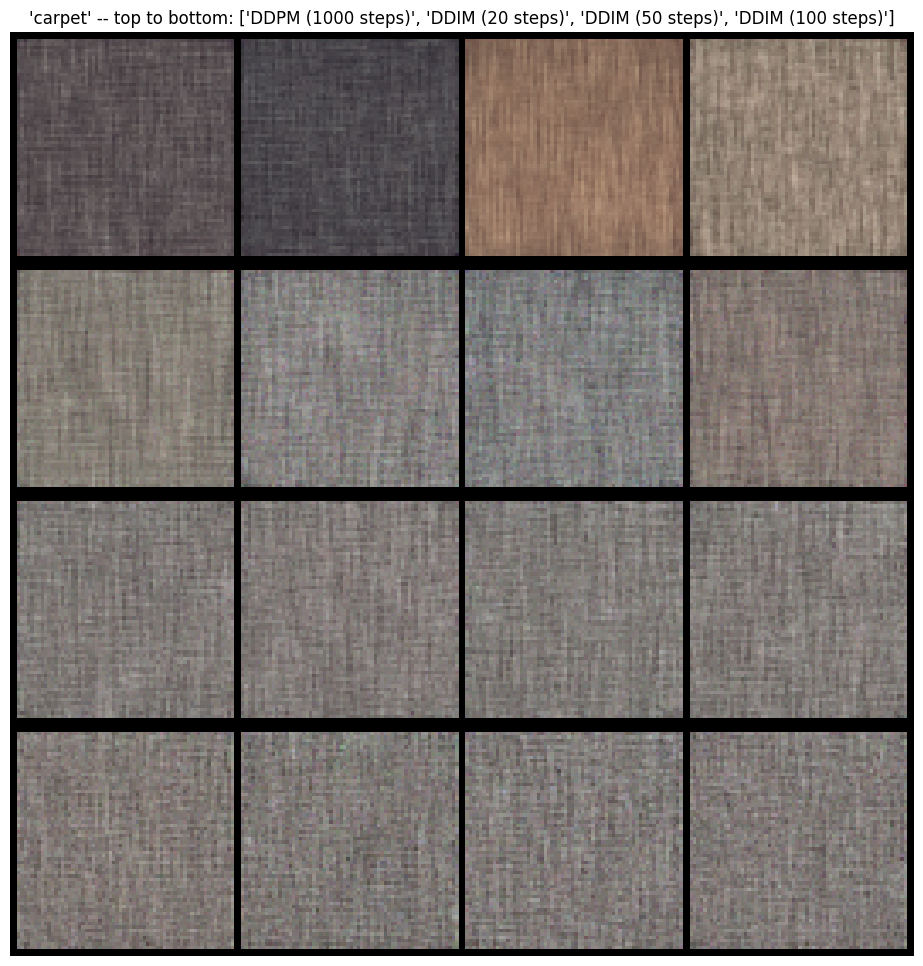

Saved to /content/local_work/samples/phase_d_ddim_sanity_mvtec_carpet.png


In [11]:
SANITY_CLASS_INDEX = 0
SANITY_CLASS_NAME = pd_class_names[SANITY_CLASS_INDEX]
SANITY_GUIDANCE_SCALE = 2.0
N_SAMPLES = 4

y_sanity = torch.full((N_SAMPLES,), SANITY_CLASS_INDEX, device=device, dtype=torch.long)
image_shape = (N_SAMPLES, 3, IMAGE_SIZE, IMAGE_SIZE)

rows, row_labels = [], []

ddpm_images = pd_diffusion.sample_cfg(pd_ema.ema_model, image_shape, y_sanity, device,
                                       guidance_scale=SANITY_GUIDANCE_SCALE)
rows.append(vutils.make_grid(denormalize(ddpm_images), nrow=N_SAMPLES))
row_labels.append("DDPM (1000 steps)")

for n_steps in [20, 50, 100]:
    ddim_images = pd_diffusion.ddim_sample_cfg(pd_ema.ema_model, image_shape, y_sanity, device,
                                                guidance_scale=SANITY_GUIDANCE_SCALE, ddim_steps=n_steps)
    rows.append(vutils.make_grid(denormalize(ddim_images), nrow=N_SAMPLES))
    row_labels.append(f"DDIM ({n_steps} steps)")

sanity_grid = torch.cat(rows, dim=1)
sanity_path = os.path.join(SAMPLES_DIR, f"phase_d_ddim_sanity_mvtec_{SANITY_CLASS_NAME}.png")
vutils.save_image(sanity_grid, sanity_path)

img = plt.imread(sanity_path)
plt.figure(figsize=(3 * N_SAMPLES, 3 * len(rows)))
plt.imshow(img)
plt.axis("off")
plt.title(f"'{SANITY_CLASS_NAME}' -- top to bottom: {row_labels}")
plt.show()
print(f"Saved to {sanity_path}")


## 10. Benchmark — speed and quality

Speed: wall-clock seconds per image. Quality: FID against real reference images. Includes a warmup pass so CUDA init cost isn't charged to whichever sampler runs first, and uses at least 2000 images so the FID number is actually trustworthy (FID under a few hundred samples is mostly estimator noise, not a real quality signal).

In [12]:
N_TIMING_IMAGES = 16
TIMING_BATCH_SIZE = 16
BENCHMARK_GUIDANCE_SCALE = 2.0
BENCHMARK_CLASS_INDEX = 0

samplers_to_benchmark = [
    ("DDPM (1000 steps)", lambda shape, y: pd_diffusion.sample_cfg(
        pd_ema.ema_model, shape, y, device, guidance_scale=BENCHMARK_GUIDANCE_SCALE)),
    ("DDIM (50 steps)", lambda shape, y: pd_diffusion.ddim_sample_cfg(
        pd_ema.ema_model, shape, y, device, guidance_scale=BENCHMARK_GUIDANCE_SCALE, ddim_steps=50)),
    ("DDIM (100 steps)", lambda shape, y: pd_diffusion.ddim_sample_cfg(
        pd_ema.ema_model, shape, y, device, guidance_scale=BENCHMARK_GUIDANCE_SCALE, ddim_steps=100)),
]

y_bench = torch.full((TIMING_BATCH_SIZE,), BENCHMARK_CLASS_INDEX, device=device, dtype=torch.long)
bench_shape = (TIMING_BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)

_ = pd_diffusion.ddim_sample_cfg(pd_ema.ema_model, bench_shape, y_bench, device,
                                  guidance_scale=BENCHMARK_GUIDANCE_SCALE, ddim_steps=10)
if device == "cuda":
    torch.cuda.synchronize()

timing_results = []
for name, sampler_fn in samplers_to_benchmark:
    if device == "cuda":
        torch.cuda.synchronize()
    start = time.time()
    n_done = 0
    while n_done < N_TIMING_IMAGES:
        sampler_fn(bench_shape, y_bench)
        n_done += TIMING_BATCH_SIZE
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - start
    timing_results.append({"sampler": name, "total_s": elapsed, "images": n_done,
                            "sec_per_image": elapsed / n_done})
    print(f"{name:>20}: {elapsed:6.1f}s for {n_done} images -> {elapsed / n_done:.3f} s/image")

fastest = min(timing_results, key=lambda r: r["sec_per_image"])
slowest = max(timing_results, key=lambda r: r["sec_per_image"])
print(f"\nSpeedup ({slowest['sampler']} -> {fastest['sampler']}): "
      f"{slowest['sec_per_image'] / fastest['sec_per_image']:.1f}x")


   DDPM (1000 steps):  154.1s for 16 images -> 9.633 s/image
     DDIM (50 steps):    7.7s for 16 images -> 0.480 s/image
    DDIM (100 steps):   15.4s for 16 images -> 0.959 s/image

Speedup (DDPM (1000 steps) -> DDIM (50 steps)): 20.1x


In [13]:
from torch_fidelity import calculate_metrics

# 2000 is the practical floor for a quotable FID. DDIM at ~0.5s/image makes this ~17 min;
# DDPM at ~10s/image would take ~5.5 hours, so DDPM is left out of the FID table by default.
# Set FID_SAMPLERS = samplers_to_benchmark to include it if you have the time.
N_FID_IMAGES = 2000
FID_SAMPLERS = [s for s in samplers_to_benchmark if not s[0].startswith("DDPM")]

FID_ROOT = os.path.join(LOCAL_ROOT, "fid_benchmark")
if os.path.exists(FID_ROOT):
    shutil.rmtree(FID_ROOT)
REAL_DIR = os.path.join(FID_ROOT, "real")
os.makedirs(REAL_DIR, exist_ok=True)

g = torch.Generator().manual_seed(0)
perm = torch.randperm(len(pd_real_dataset), generator=g).tolist()
real_indices = [perm[i % len(perm)] for i in range(min(N_FID_IMAGES, len(pd_real_dataset)))]

real_class_counts = Counter()
for i, idx in enumerate(real_indices):
    img_tensor, lbl = pd_real_dataset[idx]
    real_class_counts[lbl] += 1
    vutils.save_image(denormalize(img_tensor.unsqueeze(0))[0],
                       os.path.join(REAL_DIR, f"real_{i:04d}.png"))
print(f"Saved {len(real_indices)} real reference images (per-class: {dict(real_class_counts)})")
if len(real_indices) < 2000:
    print(f"WARNING: only {len(real_indices)} real images available. Treat FID below as "
          f"indicative, not a quotable score.")

class_pool = torch.tensor([c for c, n in real_class_counts.items() for _ in range(n)])
class_pool = class_pool[torch.randperm(len(class_pool), generator=g)]

fid_results = []
for name, sampler_fn in FID_SAMPLERS:
    gen_dir = os.path.join(FID_ROOT, name.replace(" ", "_").replace("(", "").replace(")", ""))
    os.makedirs(gen_dir, exist_ok=True)

    img_i = 0
    while img_i < len(class_pool):
        this_batch = min(TIMING_BATCH_SIZE, len(class_pool) - img_i)
        y_fid = class_pool[img_i:img_i + this_batch].to(device).long()
        images = denormalize(sampler_fn((this_batch, 3, IMAGE_SIZE, IMAGE_SIZE), y_fid))
        for img in images:
            vutils.save_image(img, os.path.join(gen_dir, f"gen_{img_i:04d}.png"))
            img_i += 1
        print(f"  {name}: {img_i}/{len(class_pool)}", end="\r")

    metrics = calculate_metrics(input1=gen_dir, input2=REAL_DIR, cuda=(device == "cuda"),
                                 isc=False, fid=True, kid=False, verbose=False)
    fid_results.append({"sampler": name, "fid": metrics["frechet_inception_distance"]})
    print(f"\n{name:>20}: FID = {metrics['frechet_inception_distance']:.2f} (n={len(class_pool)})")

timing_by_name = {r["sampler"]: r["sec_per_image"] for r in timing_results}
print("\n=== Summary: speed vs. quality ===")
for r in fid_results:
    print(f"  {r['sampler']:>20}: FID={r['fid']:6.2f}  |  {timing_by_name[r['sampler']]:.3f} s/image")


Saved 1486 real reference images (per-class: {4: 230, 1: 264, 0: 280, 3: 220, 5: 247, 2: 245})


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation mig


     DDIM (50 steps): FID = 184.54 (n=1486)

    DDIM (100 steps): FID = 212.46 (n=1486)

=== Summary: speed vs. quality ===
       DDIM (50 steps): FID=184.54  |  0.480 s/image
      DDIM (100 steps): FID=212.46  |  0.959 s/image


## 11. Gradio demo — pick a class, generate, watch it denoise

The link printed below (`...gradio.live`) only stays alive while this Colab runtime is running. If you're presenting later, re-run this notebook and relaunch shortly before you go up — free Colab disconnects after a period of idle time.

In [14]:
import gradio as gr
from PIL import Image as PILImage

N_DEMO_FRAMES = 12

DEMO_SAMPLERS = {
    "DDPM (1000 steps, slow)": lambda shape, y, gs: pd_diffusion.sample_cfg(
        pd_ema.ema_model, shape, y, device, guidance_scale=gs,
        return_trajectory=True, n_trajectory_frames=N_DEMO_FRAMES),
    "DDIM (50 steps, fast)": lambda shape, y, gs: pd_diffusion.ddim_sample_cfg(
        pd_ema.ema_model, shape, y, device, guidance_scale=gs, ddim_steps=50,
        return_trajectory=True, n_trajectory_frames=N_DEMO_FRAMES),
    "DDIM (100 steps)": lambda shape, y, gs: pd_diffusion.ddim_sample_cfg(
        pd_ema.ema_model, shape, y, device, guidance_scale=gs, ddim_steps=100,
        return_trajectory=True, n_trajectory_frames=N_DEMO_FRAMES),
}

def _tensor_to_pil(img_tensor, size=256):
    arr = denormalize(img_tensor.unsqueeze(0))[0].permute(1, 2, 0).cpu().numpy()
    return PILImage.fromarray((arr * 255).clip(0, 255).astype("uint8")).resize((size, size), PILImage.NEAREST)

@torch.no_grad()
def phase_d_generate(class_name, guidance_scale, sampler_choice):
    class_idx = pd_class_names.index(class_name)
    y = torch.tensor([class_idx], device=device, dtype=torch.long)
    final, trajectory = DEMO_SAMPLERS[sampler_choice]((1, 3, IMAGE_SIZE, IMAGE_SIZE), y, guidance_scale)

    frames = [_tensor_to_pil(f[0]) for f in trajectory]
    gif_path = os.path.join(SAMPLES_DIR, "phase_d_denoise_demo.gif")
    frames[0].save(gif_path, save_all=True, append_images=frames[1:] + [frames[-1]] * 6,
                    duration=200, loop=0)
    return _tensor_to_pil(final[0]), gif_path

demo_ui = gr.Interface(
    fn=phase_d_generate,
    inputs=[
        gr.Dropdown(choices=pd_class_names, value=pd_class_names[0], label="Texture class"),
        gr.Slider(minimum=0.5, maximum=6.0, value=2.0, step=0.5, label="Guidance scale"),
        gr.Radio(choices=list(DEMO_SAMPLERS.keys()), value="DDIM (50 steps, fast)", label="Sampler"),
    ],
    outputs=[gr.Image(label="Generated texture"),
             gr.Image(label="Denoising animation (noise -> texture)")],
    title="Conditional Texture Generator -- MVTec AD demo",
    description=("Pick a class and a sampler, then Generate. DDIM reuses the exact same "
                  "trained weights as DDPM but evaluates far fewer timesteps."),
)
demo_ui.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f5c3152a7843ec64ac.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 12. Generate the technical README

In [15]:
_n_fid = globals().get("N_FID_IMAGES", "?")
_timing_by_name = {r["sampler"]: r["sec_per_image"] for r in globals().get("timing_results", [])}

if "fid_results" in globals() and fid_results:
    _fid_lines = "\n".join(
        f"| {r['sampler']} | {r['fid']:.2f} | {_timing_by_name.get(r['sampler'], float('nan')):.3f} |"
        for r in fid_results
    )
else:
    _fid_lines = "| _(run section 10 to fill this in)_ | - | - |"

_fid_caveat = ("" if isinstance(_n_fid, int) and _n_fid >= 2000 else
               "\n> **Caveat:** FID below ~2000 samples is dominated by estimator bias. "
               "The numbers above are indicative only.\n")

readme_text = f"""# Conditional Texture Generator -- Diffusion-Based Industrial Surface Synthesis

A class-conditional DDPM implemented from scratch in PyTorch, generating industrial surface
textures conditioned on a category label (MVTec AD). Includes Classifier-Free Guidance and
DDIM accelerated sampling.

## Overview

- **Task:** class-conditional generation of industrial surface textures.
- **Dataset:** MVTec AD, defect-free images from `train/good`, {{len(MVTEC_CATEGORIES)}} categories.
- **Resolution:** {{IMAGE_SIZE}}x{{IMAGE_SIZE}} RGB.
- **Classes:** {{pd_class_names}}.

## Architecture

- U-Net noise predictor `eps_theta(x_t, t, y)`: sinusoidal timestep embeddings combined with a
  learned class embedding; residual blocks with GroupNorm + SiLU; skip connections;
  self-attention at low spatial resolutions.
- Diffusion: linear beta schedule, {{TIMESTEPS}} timesteps, closed-form `q(x_t | x_0)`.
- Classifier-Free Guidance: label dropout during training;
  `eps = eps_uncond + s * (eps_cond - eps_uncond)` at sampling time.
- EMA (decay 0.995) weights used for all sampling.

## Sampling: DDPM vs. DDIM

DDIM (Song et al., 2021) reuses the trained model unchanged but evaluates a short subsequence
of the {{TIMESTEPS}} timesteps.

| Sampler | FID (vs. real, n={{_n_fid}}) | sec/image |
|---|---|---|
{{_fid_lines}}
{{_fid_caveat}}
## Reproduction

1. Train the model with the Phase C notebook (mounts Drive, trains, checkpoints there).
2. Open this Phase D notebook, mount Drive, run every cell top to bottom -- it loads that
   checkpoint and does not train anything itself.
3. The Gradio cell launches a shareable link; it only lives as long as this Colab runtime.

## References

- Ho et al. (2020), *Denoising Diffusion Probabilistic Models*.
- Song et al. (2021), *Denoising Diffusion Implicit Models*.
- Ho & Salimans (2022), *Classifier-Free Diffusion Guidance*.
"""

readme_path = os.path.join(PROJECT_ROOT, "README.md")
with open(readme_path, "w") as f:
    f.write(readme_text)
print(f"README written to {readme_path}")
print()
print(readme_text[:600] + "...")


README written to /content/drive/MyDrive/diffusion_project/phase_c/README.md

# Conditional Texture Generator -- Diffusion-Based Industrial Surface Synthesis

A class-conditional DDPM implemented from scratch in PyTorch, generating industrial surface
textures conditioned on a category label (MVTec AD). Includes Classifier-Free Guidance and
DDIM accelerated sampling.

## Overview

- **Task:** class-conditional generation of industrial surface textures.
- **Dataset:** MVTec AD, defect-free images from `train/good`, {len(MVTEC_CATEGORIES)} categories.
- **Resolution:** {IMAGE_SIZE}x{IMAGE_SIZE} RGB.
- **Classes:** {pd_class_names}.

## Architecture

- U-Net noise predictor...
